# Backbone conformation and sugar pucker

Three results, one figure each. None of these signals affects the 0-100 score.

1. Each Leontis-Westhof class has its own suite vocabulary.
2. Correcting the torsions PARSE names raises suiteness.
3. The unusual-pucker flag is calibrated against an independent measure.

Suiteness, the 54-conformer library and the delta / Pperp cross-check are
established work (Richardson 2008; the RNA Ontology Consortium; Jain, Richardson
& Richardson, Methods in Enzymology). What is tested here is PARSE's use of them.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

_HERE = Path.cwd()
ROOT = _HERE.parent if _HERE.name == "notebooks" else _HERE
def data_file(rel):
    return ROOT / "data" / rel

# The non-redundant set throughout. The curated high-quality set is selected on
# quality and would bias every distribution here.
TORS = pd.read_csv(data_file("reference/all_uniques_features/torsions.csv"))
TORS["is_outlier"] = TORS["is_outlier"].fillna(False).astype(bool)
LW = ["cWW", "tWW", "cWH", "tWH", "cWS", "tWS", "cHH", "tHH", "cHS", "tHS", "cSS", "tSS"]
RES = TORS[TORS.lw_class.isin(LW)].copy()

# torsions.csv covers residues that are in a classified pair, so RES == TORS here.
print(f"{len(RES):,} residues in a classified pair, from "
      f"{RES.pdb_id.nunique():,} structures")

236,030 residues in a classified pair, from 1,480 structures


## 1. Which suite conformers dominate each pair class

For every residue in a classified pair, the named Richardson rotamer its
backbone sits in.

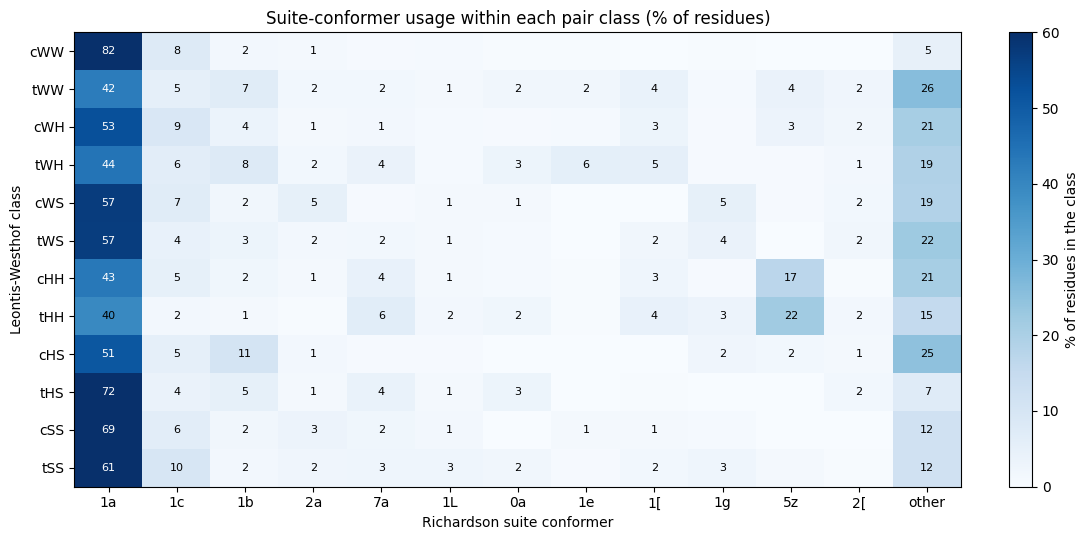

,n residues,outlier %,top conformers
class,,,
cWW,153151,13.2,"1a 82%, 1c 8%, 1b 2%, 2a 1%"
tWW,2613,32.5,"1a 42%, 1b 7%, 1c 5%, 1[ 4%"
cWH,3471,32.7,"1a 53%, 1c 9%, 1b 4%, 7r 4%"
tWH,9289,26.1,"1a 44%, 1b 8%, 1c 6%, 1e 6%"
cWS,4551,25.3,"1a 57%, 1c 7%, 1g 5%, 2a 5%"
tWS,3626,24.8,"1a 57%, 6n 5%, 1c 4%, 1g 4%"
cHH,367,36.1,"1a 43%, 5z 17%, 1c 5%, 7a 4%"
tHH,1580,26.4,"1a 40%, 5z 22%, 7a 6%, 1[ 4%"
cHS,1344,26.8,"1a 51%, 1b 11%, 1c 5%, 6g 4%"


In [2]:
ok = RES[~RES.is_outlier]
tab = pd.crosstab(ok.lw_class, ok.conformer).reindex(LW).dropna(how="all")
top = tab.sum(axis=0).sort_values(ascending=False).head(12).index
use = 100 * tab[top].div(tab.sum(axis=1), axis=0)
use["other"] = 100 - use.sum(axis=1)

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(use.values, cmap="Blues", vmin=0, vmax=60, aspect="auto")
ax.set_xticks(range(use.shape[1])); ax.set_xticklabels(use.columns)
ax.set_yticks(range(use.shape[0])); ax.set_yticklabels(use.index)
ax.set_xlabel("Richardson suite conformer"); ax.set_ylabel("Leontis-Westhof class")
ax.set_title("Suite-conformer usage within each pair class (% of residues)")
for i in range(use.shape[0]):
    for j in range(use.shape[1]):
        v = use.values[i, j]
        if v >= 1:
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if v > 40 else "black")
fig.colorbar(im, ax=ax, fraction=0.025, label="% of residues in the class")
fig.tight_layout(); plt.show()

rows = []
for lw in LW:
    d = ok[ok.lw_class == lw]
    if len(d) < 200:
        continue
    vc = d.conformer.value_counts(normalize=True)
    rows.append({"class": lw, "n residues": len(d),
                 "outlier %": round(100 * RES.loc[RES.lw_class == lw, "is_outlier"].mean(), 1),
                 "top conformers": ", ".join(f"{k} {100*v:.0f}%" for k, v in vc.head(4).items())})
display(pd.DataFrame(rows).set_index("class"))

`1a` leads every class, so the signal is what each class uses besides it. cWW is
the most concentrated (82% `1a`), the Hoogsteen-edge classes the least (40-43%).
`5z` is the clearest case: 17% of cHH and 22% of tHH residues, essentially
absent from Watson-Crick pairs.

The outlier column follows the same ordering, so these classes are both the
least A-form and the least well determined. Genuine conformational variety and
weaker density in loops and junctions cannot be separated here.

## 2. Following PARSE's backbone recommendations improves suiteness

For a residue with poor backbone, PARSE assigns a target conformer and names the
torsions whose ProSco has fired as the ones to correct.

The test below is on residues that have an assigned rotamer, suiteness under
0.5, and at least one named torsion, since that is where PARSE makes an actual
prescription. Residues where nothing fires are left out, as there is nothing to
correct. Residues with no assigned rotamer are kept separate, since their target
is only the *nearest* conformer rather than a confident one.

Test: snap the named torsions to their targets and re-score with the Richardson
classifier.

944,116 flagged residues from 2,697 structures (1,478 dropped on the reconstruction check, 0 structures failed)


,n,median torsions named,suiteness before,suiteness after,% reaching 0.5
residues,,,,,
"assigned rotamer, torsions named",258050,1.0,0.22,0.59,70.22
no assigned rotamer (target is nearest),424772,2.0,0.00,0.43,40.78


a further 261,294 flagged residues have no torsion named and are excluded: there is nothing to correct


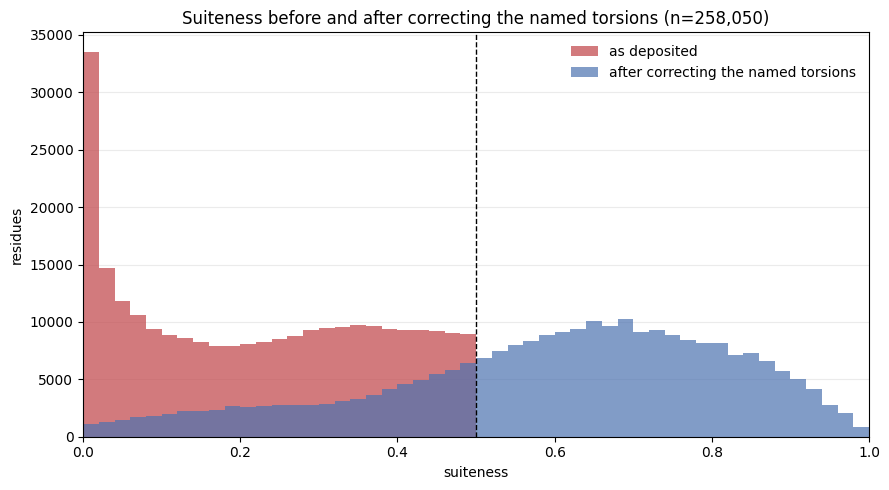

n=258,050: mean suiteness 0.22 -> 0.59; 70.2% cross 0.5

by number of torsions named:
  1 named :  59.6% reach 0.5   (n=160,735)
  2 named :  85.0% reach 0.5   (n=71,234)
  3 named :  94.5% reach 0.5   (n=21,026)
  4 named :  96.9% reach 0.5   (n=4,454)
  5 named :  98.0% reach 0.5   (n=558)


In [3]:
B = pd.read_csv(data_file("reference/backbone_recommendations.csv"))
SUM = json.load(open(data_file("reference/backbone_recommendations_summary.json")))
print(f"{SUM['n_flagged_residues']:,} flagged residues from {SUM['n_structures']:,} "
      f"structures ({SUM['n_dropped_reconstruction_mismatch']:,} dropped on the "
      f"reconstruction check, {SUM['n_failed']} structures failed)")

NAMED = "assigned rotamer, torsions named"
NEAREST = "no assigned rotamer (target is nearest)"
GROUPS = {NAMED: B[B.tier == "fixable"], NEAREST: B[B.tier == "flag_only"]}
n_nothing = int((B.tier == "review").sum())

R = pd.DataFrame([{
    "residues": k, "n": len(d),
    "median torsions named": d.n_fired.median(),
    "suiteness before": d.suiteness.mean(),
    "suiteness after": d.suiteness_after.mean(),
    "% reaching 0.5": 100 * (d.suiteness_after > 0.5).mean(),
} for k, d in GROUPS.items()]).set_index("residues")
display(R.round(2))
print(f"a further {n_nothing:,} flagged residues have no torsion named and are "
      "excluded: there is nothing to correct")

# Plotted: the residues PARSE actually makes a prescription for.
fx = GROUPS[NAMED]
bins = np.linspace(0, 1, 51)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(fx.suiteness, bins=bins, color="#C44E52", alpha=0.75, label="as deposited")
ax.hist(fx.suiteness_after, bins=bins, color="#4C72B0", alpha=0.7,
        label="after correcting the named torsions")
ax.axvline(0.5, color="k", ls="--", lw=1)
ax.set_xlim(0, 1)
ax.set_xlabel("suiteness"); ax.set_ylabel("residues")
ax.set_title(f"Suiteness before and after correcting the named torsions "
             f"(n={len(fx):,})")
ax.legend(fontsize=10, loc="upper right", frameon=False)
ax.grid(axis="y", alpha=0.25); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

print(f"n={len(fx):,}: mean suiteness {fx.suiteness.mean():.2f} -> "
      f"{fx.suiteness_after.mean():.2f}; {100*(fx.suiteness_after > 0.5).mean():.1f}% "
      "cross 0.5")
print("\nby number of torsions named:")
for k in sorted(fx.n_fired.unique())[:5]:
    d = fx[fx.n_fired == k]
    print(f"  {k} named : {100*(d.suiteness_after > 0.5).mean():5.1f}% reach 0.5   (n={len(d):,})")

These residues start entirely below 0.5, by selection. Correcting only the named
torsions, a median of one per residue, moves them to a mean of 0.59 with 70%
crossing 0.5. Residues whose target is only the nearest conformer reach 0.5
about 41% of the time, which is the right expectation for a hint rather than a
prescription.

Recovery *rises* with the number of torsions named, 60% at one to 98% at five.
Where only one fires and suiteness is still 0.22, the rest of the distortion is
spread across angles that individually pass ProSco, so the single-torsion cases
are the hard ones.

Snapping toward a cluster centre can only raise suiteness, so the direction of
change is not evidence; the recovery rate and the contrast between the two
groups are. Residues are corrected independently, so shared delta/epsilon/zeta
coupling is not propagated and these are per-residue upper bounds. A correction
that raises suiteness still has to fit the density, which is refinement's job.

## 3. The unusual-pucker flag

PARSE flags a C2'-endo sugar (by delta) inside a helical canonical cWW G-C/A-U
pair, where A-form geometry demands C3'-endo, and attaches a Pperp cross-check.

The two measures are independent: delta is the ribose ring torsion, from the
modelled sugar; Pperp is the base to 3'-phosphate perpendicular distance, which
depends on atoms in strong density and is map-robust.

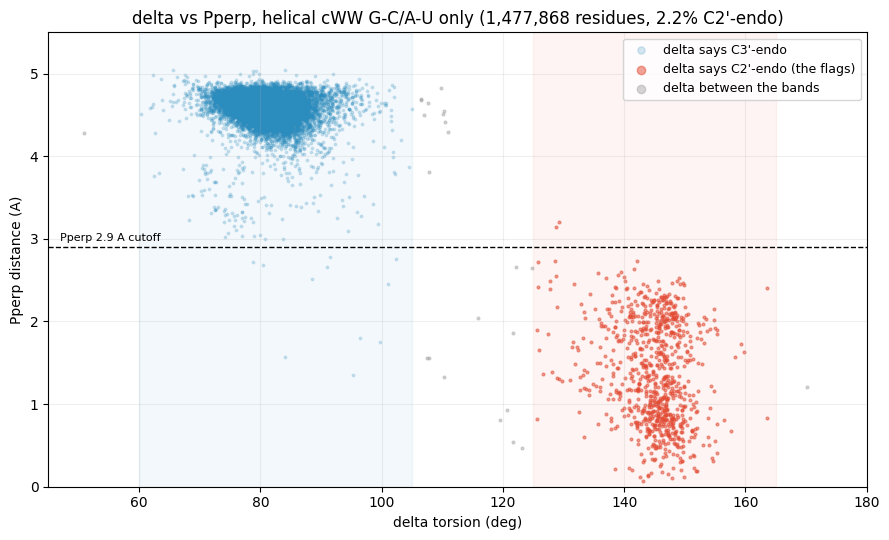

helical cWW G-C/A-U : 1,477,868 residues, 2.2% C2'-endo
delta/Pperp agreement, all 3,217,969 residues: 99.83%

32,613 unusual-pucker flags over 3,261 structures
  Pperp confirms   : 97.1%  (genuine C2'-endo)
  Pperp contradicts: 2.9%  (likely mis-modelled ribose)


In [4]:
PP = np.load(data_file("reference/pucker_delta_pperp_hist.npz"))
counts, d_edges, p_edges = PP["hist_helical"], PP["delta_edges"], PP["pperp_edges"]
n_helical = int(PP["n_helical"])
pct_c2 = 100 * counts[:, p_edges[:-1] < 2.9].sum() / counts.sum()

# Subsample the 2D histogram back to points, jittered within each bin, so the
# figure shows the whole set rather than a handful of structures.
rng = np.random.default_rng(1)
frac = 40_000 / counts.sum()
dx, px = [], []
for i in range(counts.shape[0]):
    for j in np.nonzero(counts[i])[0]:
        k = rng.binomial(int(counts[i, j]), frac)
        if k:
            dx.append(rng.uniform(d_edges[i], d_edges[i + 1], k))
            px.append(rng.uniform(p_edges[j], p_edges[j + 1], k))
dx, px = np.concatenate(dx), np.concatenate(px)
band = np.where((dx >= 60) & (dx <= 105), 3, np.where((dx >= 125) & (dx <= 165), 2, 0))

fig, ax = plt.subplots(figsize=(9, 5.5))
for b, colr, s, al, lab in ((3, "#2b8cbe", 3, 0.2, "delta says C3'-endo"),
                            (2, "#e34a33", 4, 0.5, "delta says C2'-endo (the flags)"),
                            (0, "#999999", 4, 0.4, "delta between the bands")):
    ax.scatter(dx[band == b], px[band == b], s=s, alpha=al, color=colr, label=lab)
ax.axhline(2.9, ls="--", color="k", lw=1)
ax.text(47, 2.98, "Pperp 2.9 A cutoff", fontsize=8)
ax.axvspan(60, 105, color="#2b8cbe", alpha=0.06)
ax.axvspan(125, 165, color="#e34a33", alpha=0.06)
ax.set_xlim(45, 180); ax.set_ylim(0, 5.5)
ax.set_xlabel("delta torsion (deg)"); ax.set_ylabel("Pperp distance (A)")
ax.set_title(f"delta vs Pperp, helical cWW G-C/A-U only "
             f"({n_helical:,} residues, {pct_c2:.1f}% C2'-endo)")
ax.legend(loc="upper right", fontsize=9, markerscale=3); ax.grid(alpha=0.2)
fig.tight_layout(); plt.show()

PUCK = [json.loads(l) for l in open(data_file("reference/pucker_uniques.jsonl"))]
unusual = [f for r in PUCK for f in r["unusual_pucker"]]
confirmed = 100 * np.mean([f["pperp_confirms"] for f in unusual])
base_of = lambda rid: rid.split("-")[1]
bc = pd.Series([base_of(f["res_id"]) for f in unusual
                if base_of(f["res_id"]) in list("ACGU")]).value_counts(normalize=True) * 100

print(f"helical cWW G-C/A-U : {n_helical:,} residues, {pct_c2:.1f}% C2'-endo")
print(f"delta/Pperp agreement, all {int(PP['n_residues']):,} residues: "
      f"{float(PP['agreement_pct']):.2f}%")
print(f"\n{len(unusual):,} unusual-pucker flags over {len(PUCK):,} structures")
print(f"  Pperp confirms   : {confirmed:.1f}%  (genuine C2'-endo)")
print(f"  Pperp contradicts: {100-confirmed:.1f}%  (likely mis-modelled ribose)")